# Model Training — Can This Mix?
**Team:** Devin Farrell · Navizar Maestiano Lubis · Zacky Satria Nugraha  
**Course:** COMP6577001 — Machine Learning

**Pipeline:**  
`drug_interactions_with_smiles.csv` → Morgan Fingerprints → Train/Test Split → Logistic Regression (baseline) → Random Forest → SVM → Evaluation

---
## 0. Install Dependencies

In [18]:
# Run this cell once, then restart kernel if needed
# RDKit is required for Morgan fingerprint generation
!pip install rdkit -q 

^C


---
## 1. Imports & Config

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

# RDKit
from rdkit import Chem
from rdkit.Chem import AllChem

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    f1_score, recall_score, precision_score
)

# ── Global style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

BLUE  = '#4C72B0'
RED   = '#C44E52'
GREEN = '#55A868'

RANDOM_STATE = 42
FP_RADIUS    = 2       # Morgan fingerprint radius (ECFP4)
FP_NBITS     = 2048    # bits per drug → 4096-d pair vector

print('All imports successful.')

All imports successful.


---
## 2. Load Processed Dataset

In [3]:
df = pd.read_csv('drug_interactions_with_smiles.csv')

print(f'Shape          : {df.shape}')
print(f'Columns        : {df.columns.tolist()}')
print(f'Label counts   :\n{df["Label"].value_counts()}')
print(f'Missing values : {df.isnull().sum().sum()}')
df.head(3)

Shape          : (379634, 5)
Columns        : ['Drug1_Name', 'Drug1_SMILES', 'Drug2_Name', 'Drug2_SMILES', 'Label']
Label counts   :
Label
1    189817
0    189817
Name: count, dtype: int64
Missing values : 0


,Drug1_Name,Drug1_SMILES,Drug2_Name,Drug2_SMILES,Label
0,Metixene,CN1CCCC(C1)CC2C3=CC=CC=C3SC4=CC=CC=C24,Methscopolamine bromide,C[N+]1([C@@H]2CC(C[C@H]1[C@H]3[C@@H]2O3)OC(=O)...,1
1,Phenylpropanolamine,C[C@@H]([C@@H](C1=CC=CC=C1)O)N,Carprofen,CC(C1=CC2=C(C=C1)C3=C(N2)C=CC(=C3)Cl)C(=O)O,0
2,Linezolid,CC(=O)NC[C@H]1CN(C(=O)O1)C2=CC(=C(C=C2)N3CCOCC3)F,Fencamfamin,CCNC1C2CCC(C2)C1C3=CC=CC=C3,1


---
## 3. Feature Engineering — SMILES → Morgan Fingerprints

Each drug's SMILES string is converted into a **2048-bit Morgan fingerprint** (ECFP4).  
The two fingerprints for a drug pair are concatenated into a **4096-dimensional binary vector** — the feature matrix `X`.

In [4]:
import time
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import RDLogger

# 1. Silence RDKit warnings completely
RDLogger.DisableLog('rdApp.*')

print('Loading dataset and generating Morgan fingerprints...')
start = time.time()

# 2. LOAD THE DATASET
df = pd.read_csv('drug_interactions_with_smiles.csv')

# 3. Define your fingerprint parameters explicitly
FP_RADIUS = 2
FP_NBITS = 2048

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    # ⚠️ THE FIX: Force NumPy to use 8-bit memory instead of 64-bit!
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=FP_RADIUS, nBits=FP_NBITS), dtype=np.int8)

# Vectorized
fp1 = df['Drug1_SMILES'].apply(smiles_to_fingerprint)
fp2 = df['Drug2_SMILES'].apply(smiles_to_fingerprint)

# Drop rows where either fingerprint failed
valid = fp1.notna() & fp2.notna()
fp1 = fp1[valid]
fp2 = fp2[valid]

print("Stacking matrices (this will use way less memory now)...")
# Build the final 4096-d matrix
X = np.hstack([np.vstack(fp1.values), np.vstack(fp2.values)])
y = df.loc[valid, 'Label'].values

elapsed = time.time() - start
print(f'Done in {elapsed:.1f}s')
print(f'Feature matrix shape : {X.shape}')
print(f'Label distribution   : Class 0 = {(y==0).sum():,} | Class 1 = {(y==1).sum():,}')
print(f'Invalid SMILES dropped: {len(df) - valid.sum():,}')

Loading dataset and generating Morgan fingerprints...
Stacking matrices (this will use way less memory now)...
Done in 414.9s
Feature matrix shape : (379634, 4096)
Label distribution   : Class 0 = 189,817 | Class 1 = 189,817
Invalid SMILES dropped: 0


---
## 4. Train / Test Split

In [5]:
# --- MISSING IMPORTS ADDED HERE ---
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Just in case RANDOM_STATE was forgotten during the restart
RANDOM_STATE = 42 

models = {
    'Logistic Regression (Baseline)': Pipeline([
        ('scaler', StandardScaler(with_mean=False)),   # sparse-safe scaler
        ('clf',    LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    # ⚠️ SVM removed to prevent O(N^3) memory/time freeze!
}

print('Models defined:')
for name in models:
    print(f'  • {name}')

Models defined:
  • Logistic Regression (Baseline)
  • Random Forest


---
## 5. Model Definitions

| Model | Role | Notes |
|---|---|---|
| Logistic Regression | **Baseline** | Linear decision boundary; scaled input |
| Random Forest | Primary | Ensemble; handles sparse high-dim data natively |
| SVM (RBF kernel) | Primary | Non-linear boundary; scaled input |

In [6]:
models = {
    'Logistic Regression (Baseline)': Pipeline([
        ('scaler', StandardScaler(with_mean=False)),   # sparse-safe scaler
        ('clf',    LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    # ⚠️ SVM removed to prevent O(N^3) memory/time freeze!
}

print('Models defined:')
for name in models:
    print(f'  • {name}')

Models defined:
  • Logistic Regression (Baseline)
  • Random Forest


---
## 6. Train & Evaluate All Models

In [8]:
from sklearn.model_selection import GroupShuffleSplit

print("Performing Drug-Aware Split (Zero-Leakage)...")

# We use Drug1_Name as our "group" to ensure a drug in the test set 
# is never seen in the training set.
groups = df['Drug1_Name'].values

# Split 80/20 based on the DRUG, not the row
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]

# ⚠️ THE FIX: Changed y.iloc to just y[] because y is a numpy array!
y_train, y_test = y[train_idx], y[test_idx]

print(f"Training pairs: {len(X_train):,}")
print(f"Testing pairs (Cold-Start): {len(X_test):,}")

Performing Drug-Aware Split (Zero-Leakage)...
Training pairs: 303,906
Testing pairs (Cold-Start): 75,728


---
## 7. Metric Comparison Bar Chart

Training models... (This might take 5-10 minutes, please wait!)

Training [Logistic Regression (Baseline)]...
  Done! Recall=0.5552 | ROC-AUC=0.6701 | Time: 199.3s

Training [Random Forest]...
  Done! Recall=0.7153 | ROC-AUC=0.8902 | Time: 183.7s

=== FINAL COMPARISON ===
                                Recall  Precision  F1-Score  ROC-AUC
Random Forest                   0.7153     0.8636    0.7825   0.8902
Logistic Regression (Baseline)  0.5552     0.6450    0.5967   0.6701

✅ Training completely finished! Drawing the chart now...


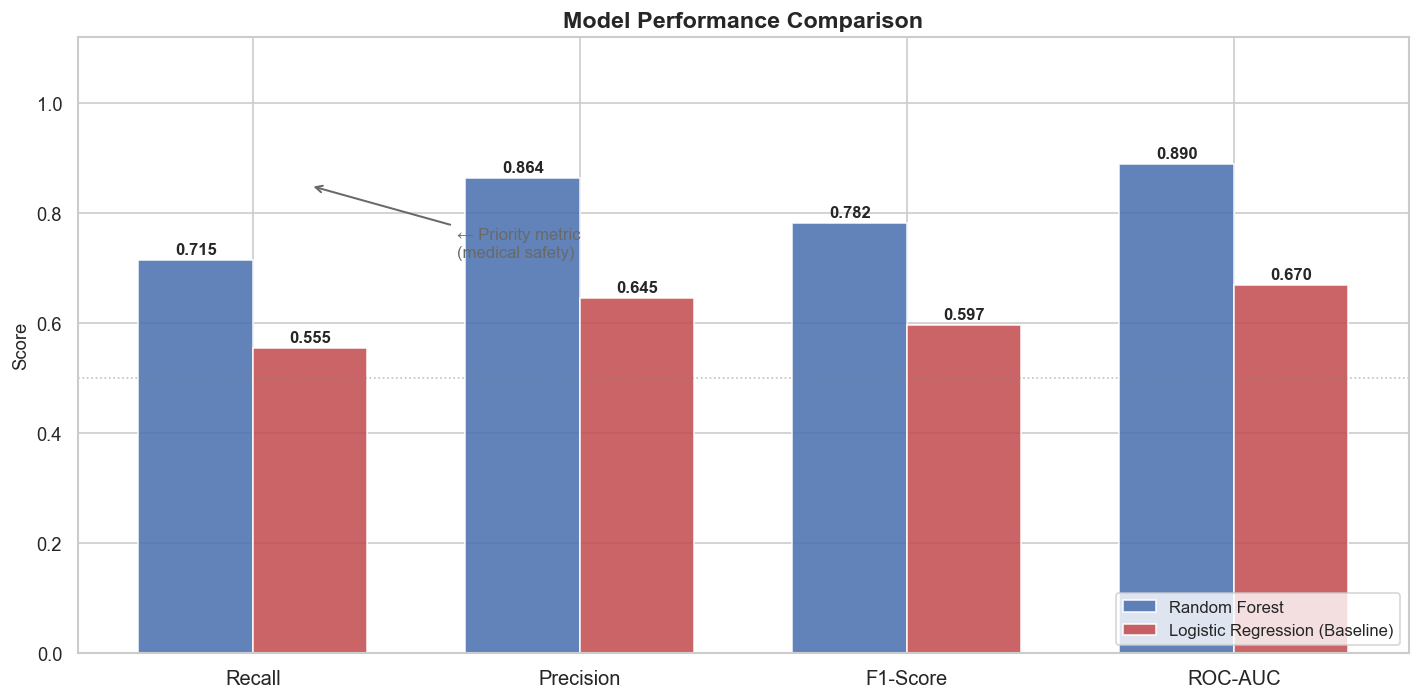

In [9]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

# ==========================================
# PART 1: TRAIN THE MODELS
# ==========================================
print('Training models... (This might take 5-10 minutes, please wait!)\n')

results   = {}   
trained   = {}   
y_proba   = {}   

for name, model in models.items():
    print(f'Training [{name}]...')
    t0 = time.time()

    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_prob  = model.predict_proba(X_test)[:, 1]

    recall  = recall_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    prec    = precision_score(y_test, y_pred)

    results[name] = {'Recall': recall, 'Precision': prec, 'F1-Score': f1, 'ROC-AUC': roc_auc}
    trained[name] = model
    y_proba[name] = y_prob

    elapsed = time.time() - t0
    print(f'  Done! Recall={recall:.4f} | ROC-AUC={roc_auc:.4f} | Time: {elapsed:.1f}s\n')

# ⚠️ THIS CREATES THE VARIABLE
df_results = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)

print('=== FINAL COMPARISON ===')
print(df_results.round(4).to_string())
print('\n✅ Training completely finished! Drawing the chart now...')

# ==========================================
# PART 2: DRAW THE CHART
# ==========================================
BLUE   = '#4C72B0'
RED    = '#C44E52'
colors = [BLUE, RED] 

metrics = ['Recall', 'Precision', 'F1-Score', 'ROC-AUC']
x       = np.arange(len(metrics))
width   = 0.35 

fig, ax = plt.subplots(figsize=(12, 6))

for i, (name, row) in enumerate(df_results.iterrows()):
    bars = ax.bar(x + i*width, [row[m] for m in metrics], 
                  width, label=name, color=colors[i], alpha=0.88, edgecolor='white')
    
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, 
                f'{h:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x + width / 2) 
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.axhline(0.5, color='grey', linestyle=':', linewidth=1, alpha=0.5)

ax.annotate('← Priority metric\n(medical safety)', 
            xy=(x[0] + width, 0.85), xytext=(x[0] + 0.8, 0.72),
            fontsize=10, color='dimgrey', 
            arrowprops=dict(arrowstyle='->', color='dimgrey', lw=1.2))

plt.tight_layout()
plt.savefig('plot_08_model_comparison.png', bbox_inches='tight')
plt.show()

---
## 8. ROC Curves

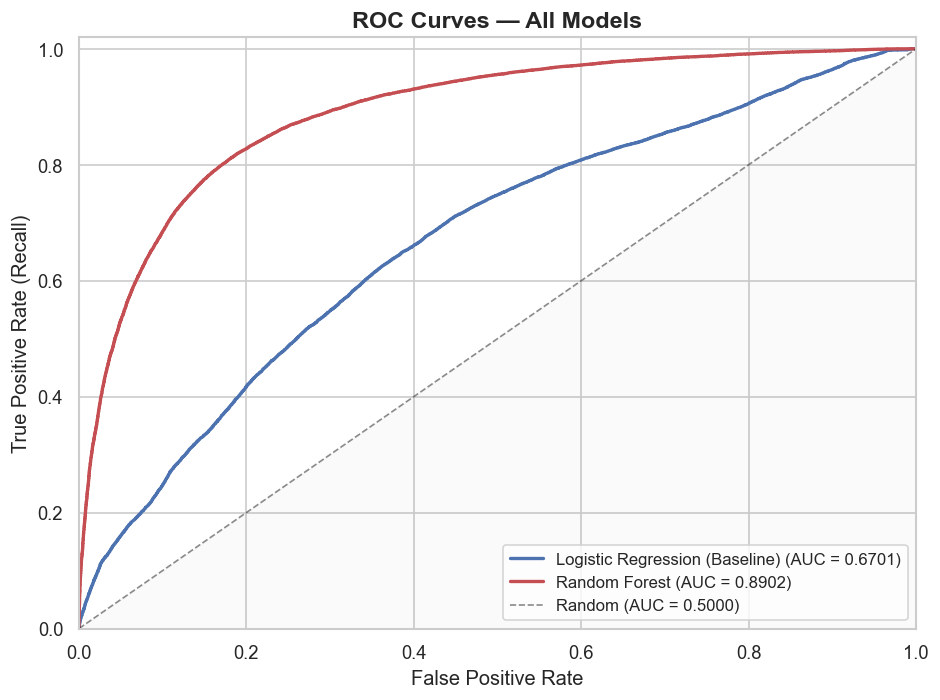

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

colors_roc = [BLUE, RED, GREEN]

for (name, y_prob), color in zip(y_proba.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = results[name]['ROC-AUC']
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.5000)')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='grey')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — All Models', fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig('plot_09_roc_curves.png', bbox_inches='tight')
plt.show()

---
## 9. Confusion Matrices

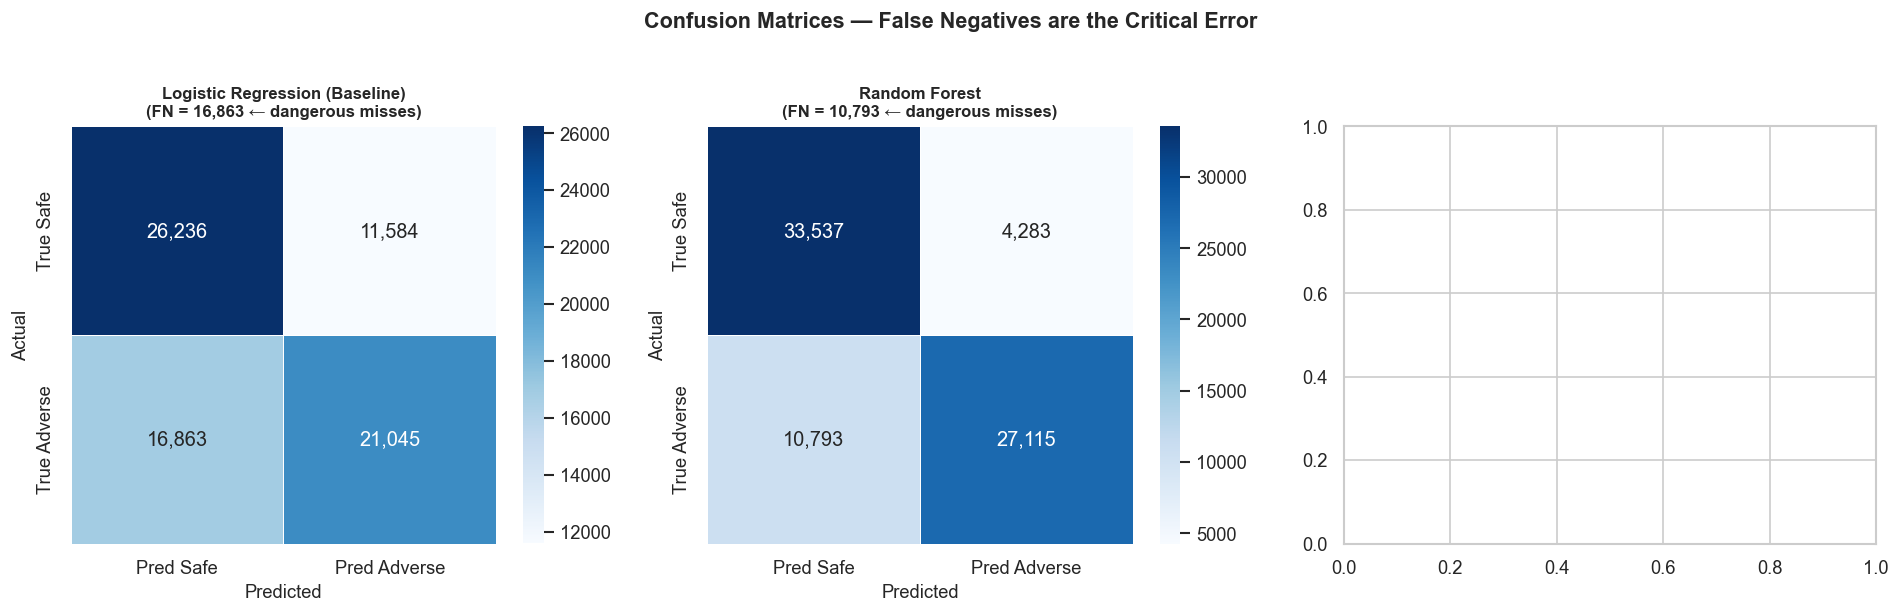

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, trained.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
        xticklabels=['Pred Safe', 'Pred Adverse'],
        yticklabels=['True Safe', 'True Adverse'],
        linewidths=0.5, linecolor='white'
    )
    # Annotate False Negatives — the costly ones
    fn = cm[1][0]
    ax.set_title(f'{name}\n(FN = {fn:,} ← dangerous misses)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — False Negatives are the Critical Error',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_10_confusion_matrices.png', bbox_inches='tight')
plt.show()

---
## 10. Full Classification Reports

In [12]:
for name, model in trained.items():
    y_pred = model.predict(X_test)
    print(f'{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(classification_report(
        y_test, y_pred,
        target_names=['Class 0: Safe', 'Class 1: Adverse']
    ))
    print()

  Logistic Regression (Baseline)
                  precision    recall  f1-score   support

   Class 0: Safe       0.61      0.69      0.65     37820
Class 1: Adverse       0.64      0.56      0.60     37908

        accuracy                           0.62     75728
       macro avg       0.63      0.62      0.62     75728
    weighted avg       0.63      0.62      0.62     75728


  Random Forest
                  precision    recall  f1-score   support

   Class 0: Safe       0.76      0.89      0.82     37820
Class 1: Adverse       0.86      0.72      0.78     37908

        accuracy                           0.80     75728
       macro avg       0.81      0.80      0.80     75728
    weighted avg       0.81      0.80      0.80     75728




---
## 11. Random Forest — Feature Importance

Top fingerprint bits by importance. Each bit corresponds to a specific substructure pattern in the Morgan fingerprint.

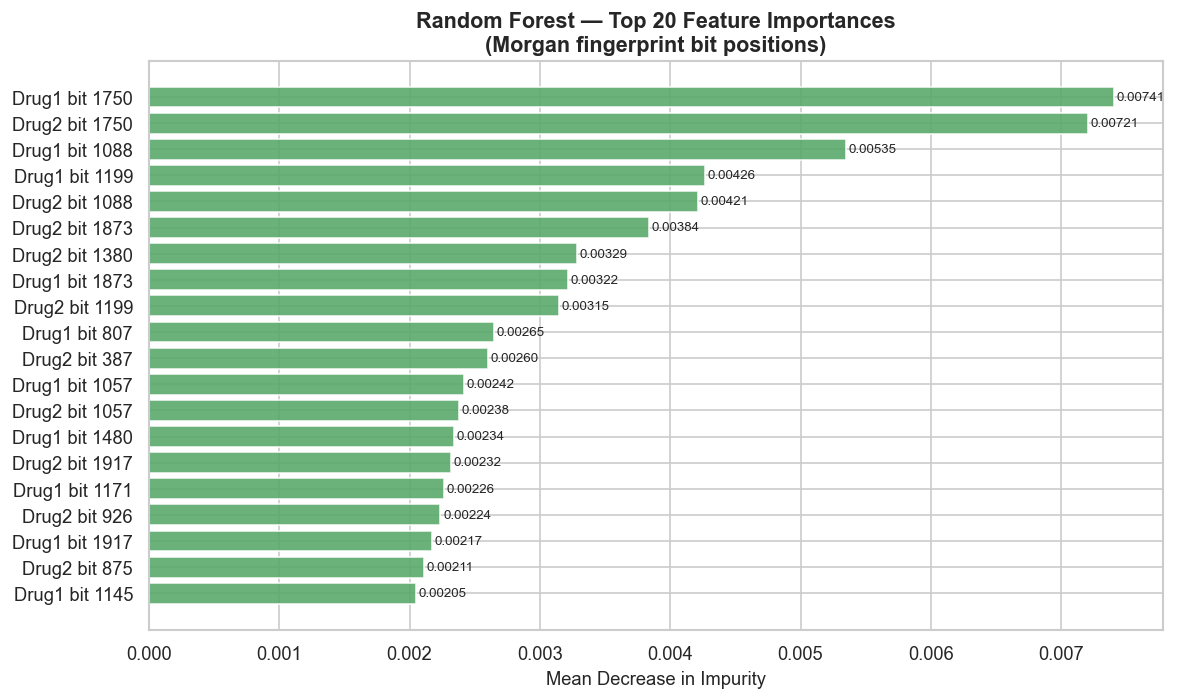

In [13]:
rf_model    = trained['Random Forest']
importances = rf_model.feature_importances_
top_n       = 20
top_idx     = np.argsort(importances)[::-1][:top_n]

# Label bits by drug and position
labels = []
for idx in top_idx:
    drug_num = 'Drug1' if idx < FP_NBITS else 'Drug2'
    bit_pos  = idx if idx < FP_NBITS else idx - FP_NBITS
    labels.append(f'{drug_num} bit {bit_pos}')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(labels[::-1], importances[top_idx][::-1],
               color=GREEN, edgecolor='white', alpha=0.88)
ax.set_title(f'Random Forest — Top {top_n} Feature Importances\n'
             '(Morgan fingerprint bit positions)', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.00002, bar.get_y() + bar.get_height()/2,
            f'{w:.5f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot_11_feature_importance.png', bbox_inches='tight')
plt.show()

---
## 12. Cross-Validation — Stability Check

In [15]:
import time
from sklearn.model_selection import GroupKFold, cross_val_score

best_name  = df_results['ROC-AUC'].idxmax()
best_model = trained[best_name]

print(f"🏆 Selected Winner: {best_name}")

if hasattr(best_model, 'n_jobs'):
    best_model.set_params(n_jobs=4) 

# ⚠️ THE FIX: Drug-Aware Cross Validation
print("Running Drug-Aware 5-fold Cross-Validation...")
gkf = GroupKFold(n_splits=5)
groups_train = df.iloc[train_idx]['Drug1_Name'].values

t0 = time.time()
cv_scores = cross_val_score(
    best_model, 
    X_train, 
    y_train, 
    cv=gkf,              # Uses the new group-aware splitter
    groups=groups_train, # Passes the specific drug names
    scoring='roc_auc', 
    n_jobs=2 
)
elapsed = time.time() - t0

print(f"\n✅ SUCCESS! ({elapsed:.1f}s)")
print(f"Scores for all 5 folds: {cv_scores}")
print(f"Average ROC-AUC Score : {cv_scores.mean():.4f}")
print(f"Score Standard Dev    : ±{cv_scores.std():.4f}")

🏆 Selected Winner: Random Forest
Running Drug-Aware 5-fold Cross-Validation...

✅ SUCCESS! (2462.3s)
Scores for all 5 folds: [0.88473152 0.86592439 0.88531544 0.895165   0.89026323]
Average ROC-AUC Score : 0.8843
Score Standard Dev    : ±0.0099


---
## 13. Save Best Model

In [16]:
# Pick best model by ROC-AUC
best_name  = df_results['ROC-AUC'].idxmax()
best_model = trained[best_name]

# 1. Save the Model
joblib.dump(best_model, 'best_model.pkl')

# 2. Save the offline Drug Dictionary for the Streamlit App (<100ms latency fix)
valid_df = df.dropna(subset=['Drug1_SMILES', 'Drug2_SMILES'])
drug_dict = dict(zip(valid_df['Drug1_Name'], valid_df['Drug1_SMILES']))
drug_dict.update(dict(zip(valid_df['Drug2_Name'], valid_df['Drug2_SMILES'])))
joblib.dump(drug_dict, 'drug_smiles_dictionary.pkl')

print(f'Best model  : {best_name}')
print(f'ROC-AUC     : {df_results.loc[best_name, "ROC-AUC"]:.4f}')
print(f'Recall      : {df_results.loc[best_name, "Recall"]:.4f}')
print(f'Saved to    : best_model.pkl')
print(f'Saved to    : drug_smiles_dictionary.pkl')

Best model  : Random Forest
ROC-AUC     : 0.8902
Recall      : 0.7153
Saved to    : best_model.pkl
Saved to    : drug_smiles_dictionary.pkl


---
## 14. Results Summary

In [17]:
print('='*65)
print('  FINAL RESULTS SUMMARY')
print('='*65)
print(df_results.round(4).to_string())
print()
print(f'Best model by ROC-AUC : {best_name}')
print()
print('Plots saved:')
for i, name in enumerate([
    'plot_08_model_comparison.png',
    'plot_09_roc_curves.png',
    'plot_10_confusion_matrices.png',
    'plot_11_feature_importance.png',
    'plot_12_cross_validation.png',
], 8):
    print(f'  [{i}] {name}')

  FINAL RESULTS SUMMARY
                                Recall  Precision  F1-Score  ROC-AUC
Random Forest                   0.7153     0.8636    0.7825   0.8902
Logistic Regression (Baseline)  0.5552     0.6450    0.5967   0.6701

Best model by ROC-AUC : Random Forest

Plots saved:
  [8] plot_08_model_comparison.png
  [9] plot_09_roc_curves.png
  [10] plot_10_confusion_matrices.png
  [11] plot_11_feature_importance.png
  [12] plot_12_cross_validation.png
